# Analyzing Customer Behavior for E-commerce Insights

**Applicant:** Fianko Junior Owusu  
**Role:** Intelligent Systems Services Engineer  
**Organization:** Npontu Technologies Ltd

## Objective

This project analyses synthetic customer activity from an e-commerce platform. It cleans imperfect data, creates useful customer-behaviour features, explores business patterns, demonstrates partitioned processing with Dask, and trains a model to predict customer churn.

**Business question:** Which customers are likely to stop purchasing, and what actions can the company take to retain them?

## 1. Import the analysis functions

The complete, commented implementation is stored in `analysis.py`. Keeping reusable functions outside the notebook makes the project easier to test, maintain, and deploy.

In [1]:
from analysis import (
    generate_synthetic_data,
    clean_and_engineer,
    perform_eda,
    run_dask_analysis,
    train_churn_model,
    create_business_recommendations,
)
from IPython.display import Image, display
import pandas as pd
pd.set_option("display.max_columns", 50)

## 2. Generate the synthetic dataset

The generated data represents customer demographics, browsing behaviour, purchase history, product interactions, support activity, and churn. Missing values, invalid entries, and duplicates are deliberately added so the cleaning process can be demonstrated.

In [2]:
raw_df = generate_synthetic_data(n_customers=12000)
print(f"Dataset shape: {raw_df.shape}")
raw_df.head()

Dataset shape: (12060, 19)


,customer_id,age,gender,city,device,membership,signup_date,last_purchase_date,website_visits,pages_viewed,avg_session_minutes,purchases,total_spent,cart_additions,abandoned_carts,support_tickets,email_open_rate,discount_usage,churn
0,CUST-000001,37.0,Female,Accra,Mobile,Basic,2024-09-22,2026-05-04,13,65,4.58,8,1306.66,14,6,3,0.713,0.165,1
1,CUST-000002,23.0,Male,Accra,Mobile,Silver,2024-01-14,2026-06-22,14,84,7.32,9,494.44,15,6,3,0.704,0.633,0
2,CUST-000003,42.0,Female,Accra,Mobile,Basic,2026-01-30,2026-07-12,14,56,21.65,8,340.28,10,2,2,0.703,0.166,0
3,CUST-000004,44.0,Male,Accra,Mobile,Basic,2026-02-25,2026-07-11,15,105,6.87,4,225.36,4,0,2,0.336,0.470,0
4,CUST-000005,18.0,Male,Tema,Desktop,Basic,2024-04-30,2026-07-13,16,48,7.65,5,262.15,9,4,0,0.438,0.547,0


In [3]:
raw_df.info()
raw_df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 12060 entries, 0 to 12059
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          12060 non-null  str           
 1   age                  11938 non-null  float64       
 2   gender               12060 non-null  str           
 3   city                 12060 non-null  str           
 4   device               12060 non-null  str           
 5   membership           12060 non-null  str           
 6   signup_date          12060 non-null  datetime64[us]
 7   last_purchase_date   12060 non-null  datetime64[us]
 8   website_visits       12060 non-null  int64         
 9   pages_viewed         12060 non-null  int64         
 10  avg_session_minutes  11939 non-null  float64       
 11  purchases            12060 non-null  int64         
 12  total_spent          12060 non-null  float64       
 13  cart_additions       12060 non-null  int64

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,12060,12000,CUST-000361,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,11938.0,NaN,NaN,NaN,34.538784,18.0,27.0,34.0,41.0,150.0,11.896536
gender,12060,3,Male,5989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,12060,6,Accra,5037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,12060,3,Mobile,8180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership,12060,3,Basic,7410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,12060,NaN,NaN,NaN,2024-06-26 00:04:17.910447,2022-07-18 00:00:00,2023-07-09 00:00:00,2024-06-26 00:00:00,2025-06-11 00:00:00,2026-06-16 00:00:00,NaN
last_purchase_date,12060,NaN,NaN,NaN,2026-05-25 08:46:12.537313,2025-07-16 00:00:00,2026-05-05 00:00:00,2026-06-10 00:00:00,2026-07-01 06:00:00,2026-07-16 00:00:00,NaN
website_visits,12060.0,NaN,NaN,NaN,14.990713,2.0,12.0,15.0,17.0,32.0,3.874053
pages_viewed,12060.0,NaN,NaN,NaN,67.277612,6.0,42.0,64.0,90.0,203.0,31.417675


## 3. Data cleaning and feature engineering

The cleaning stage removes duplicate customer IDs, replaces impossible ages and negative spending with missing values, and imputes numeric missing values using the median.

New features include customer tenure, purchase recency, average order value, cart-abandonment rate, monthly purchase frequency, engagement score, and age group. Numeric standardisation and categorical encoding are performed later inside the modelling pipeline to prevent data leakage.

In [4]:
clean_df, quality_report = clean_and_engineer(raw_df)
quality_report

{'before_cleaning': {'rows': 12060,
  'duplicate_customer_ids': 60,
  'missing_values': 363,
  'invalid_ages': 31,
  'negative_spend': 30},
 'after_cleaning': {'rows': 12000,
  'duplicate_customer_ids': 0,
  'missing_values': 0,
  'invalid_ages': 0,
  'negative_spend': 0}}

In [5]:
clean_df[[
    "customer_id", "recency_days", "tenure_days", "average_order_value",
    "cart_abandonment_rate", "purchase_frequency", "engagement_score", "churn"
]].head()

,customer_id,recency_days,tenure_days,average_order_value,cart_abandonment_rate,purchase_frequency,engagement_score,churn
0,CUST-000001,73,662,163.332500,0.428571,0.362538,21.1490,1
1,CUST-000002,24,914,54.937778,0.400000,0.295405,24.9620,0
2,CUST-000003,4,167,42.535000,0.200000,1.437126,24.3365,0
3,CUST-000004,5,141,56.340000,0.000000,0.851064,25.4055,0
4,CUST-000005,3,807,52.430000,0.444444,0.185874,18.2165,0


## 4. Exploratory data analysis

The analysis compares churn, customer activity, spending, membership, device type, and location. The charts are also saved as high-resolution PNG files in `outputs/charts`.

In [6]:
eda_insights = perform_eda(clean_df)
eda_insights

{'customers': 12000,
 'churn_rate_percent': 26.77,
 'average_customer_spend': 444.33,
 'average_purchases': 5.98,
 'highest_churn_membership': 'Basic',
 'highest_churn_device': 'Tablet'}

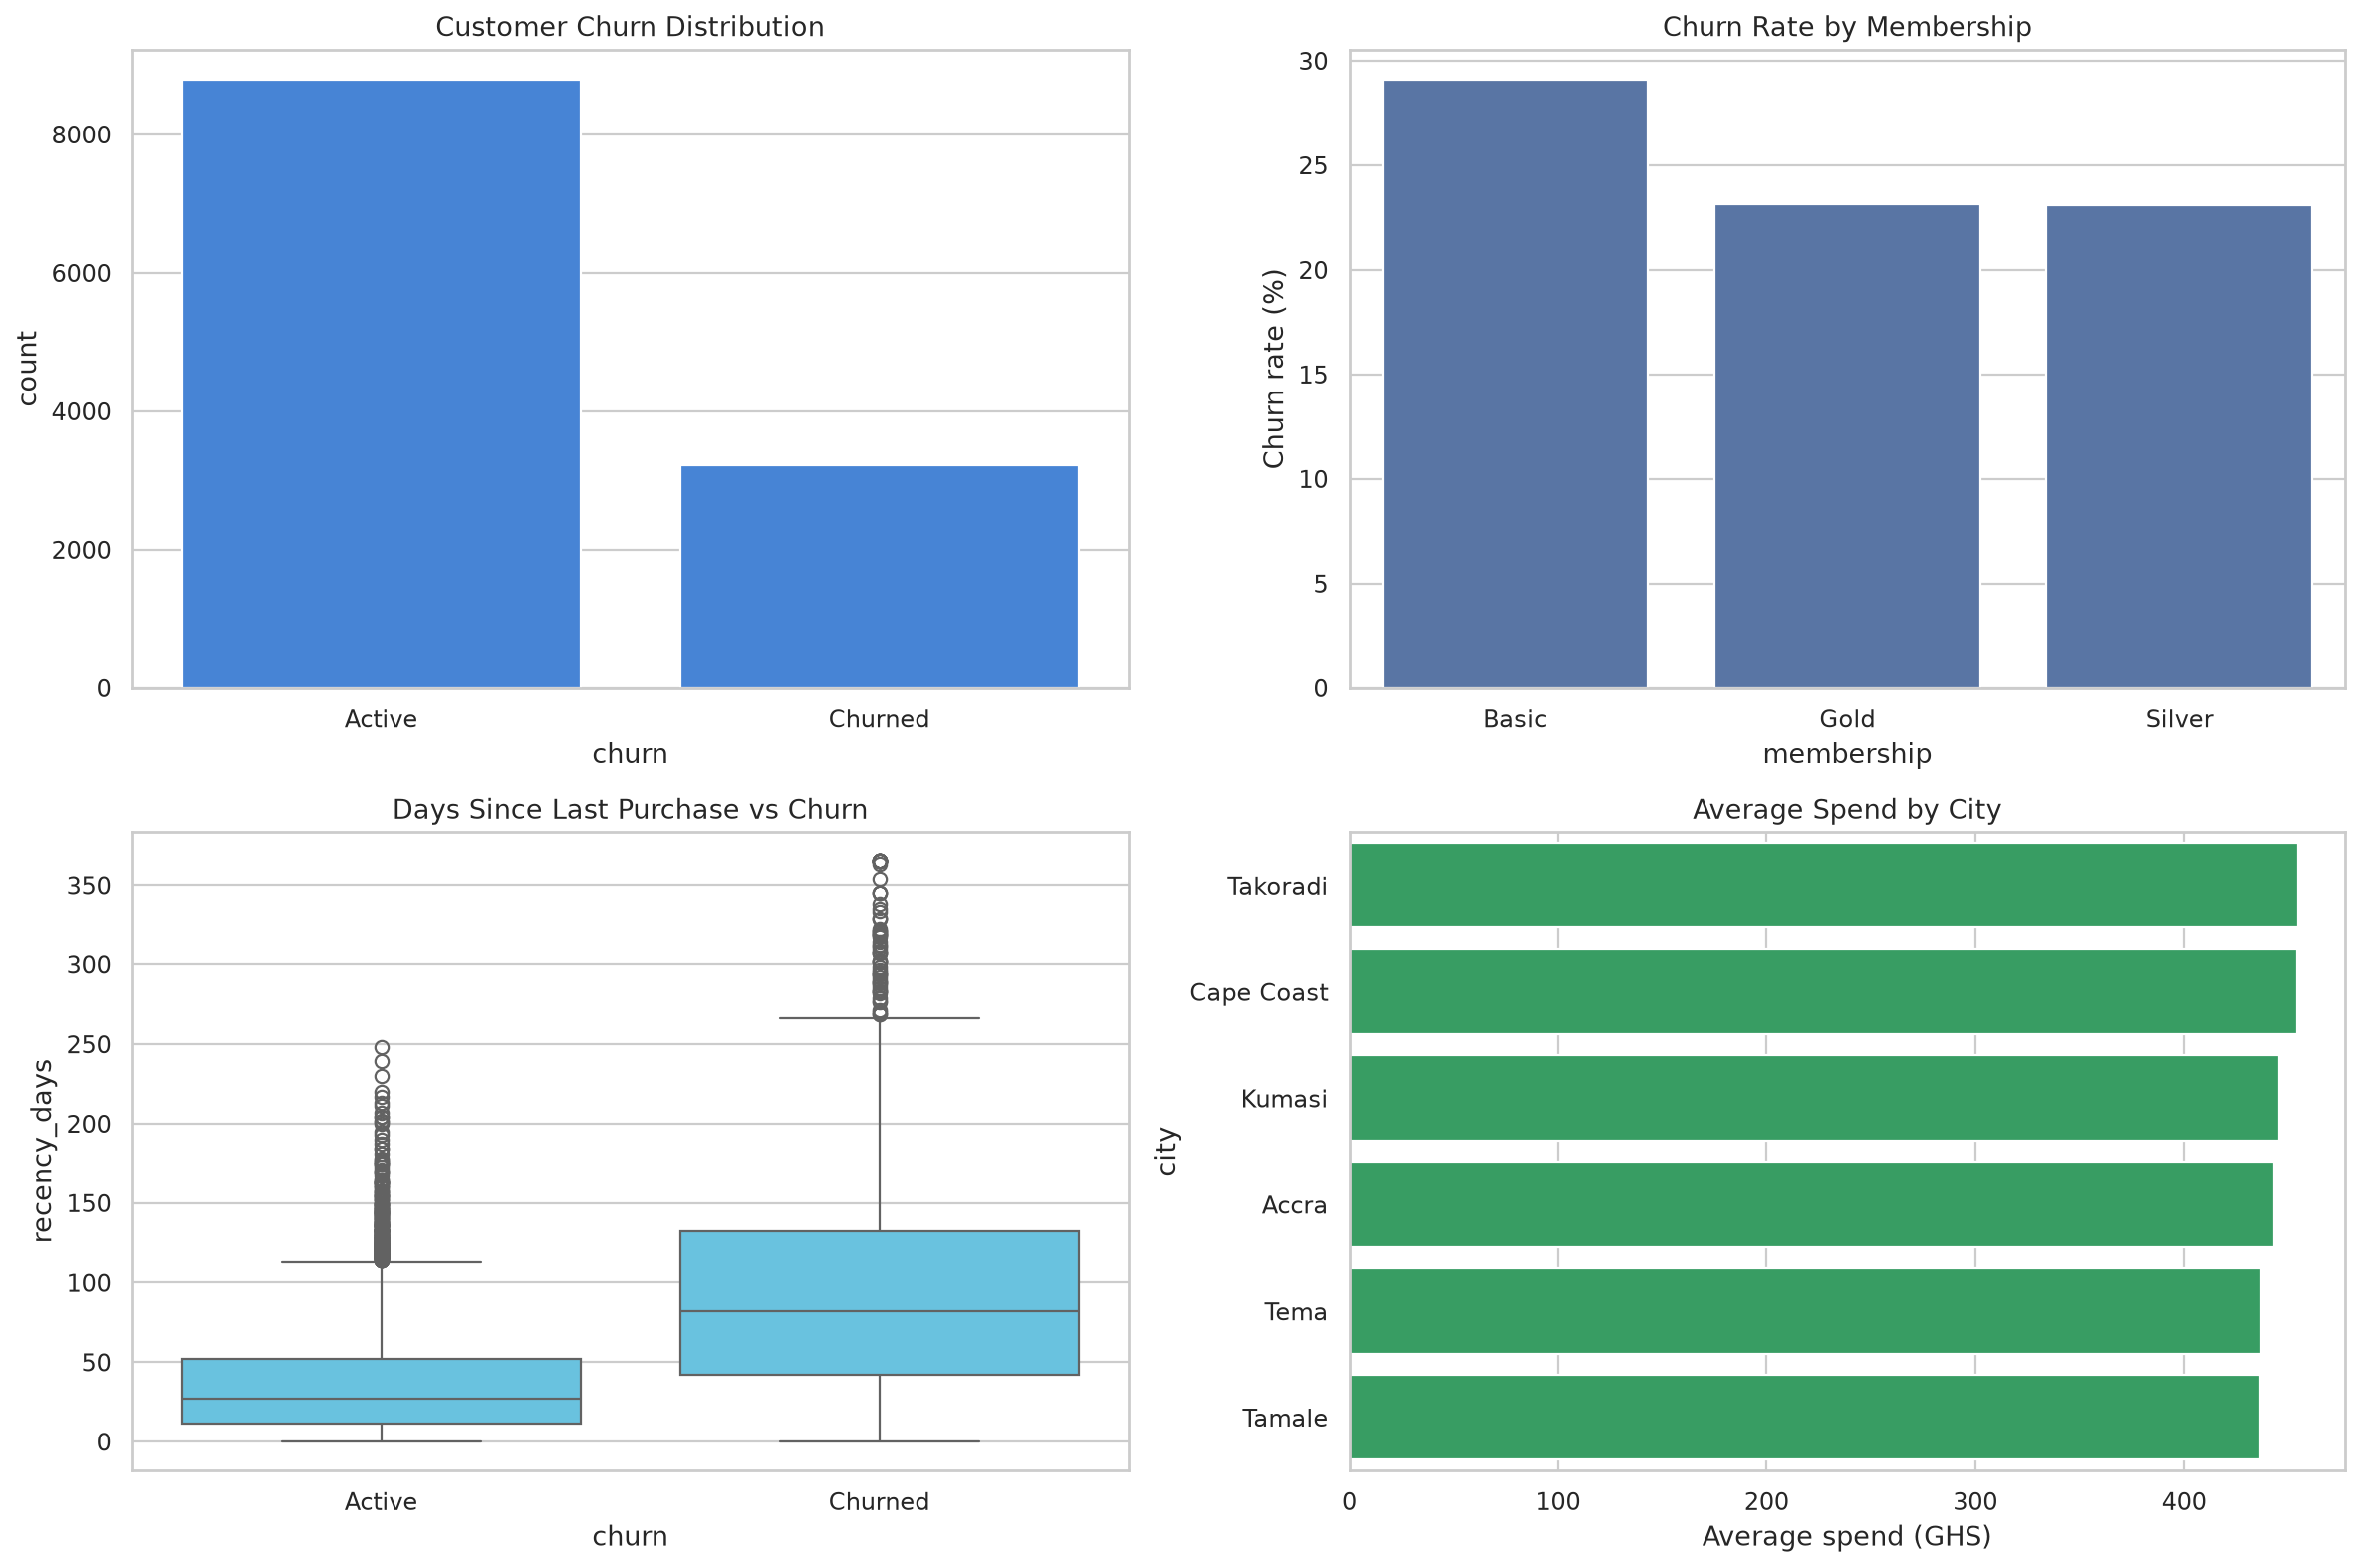

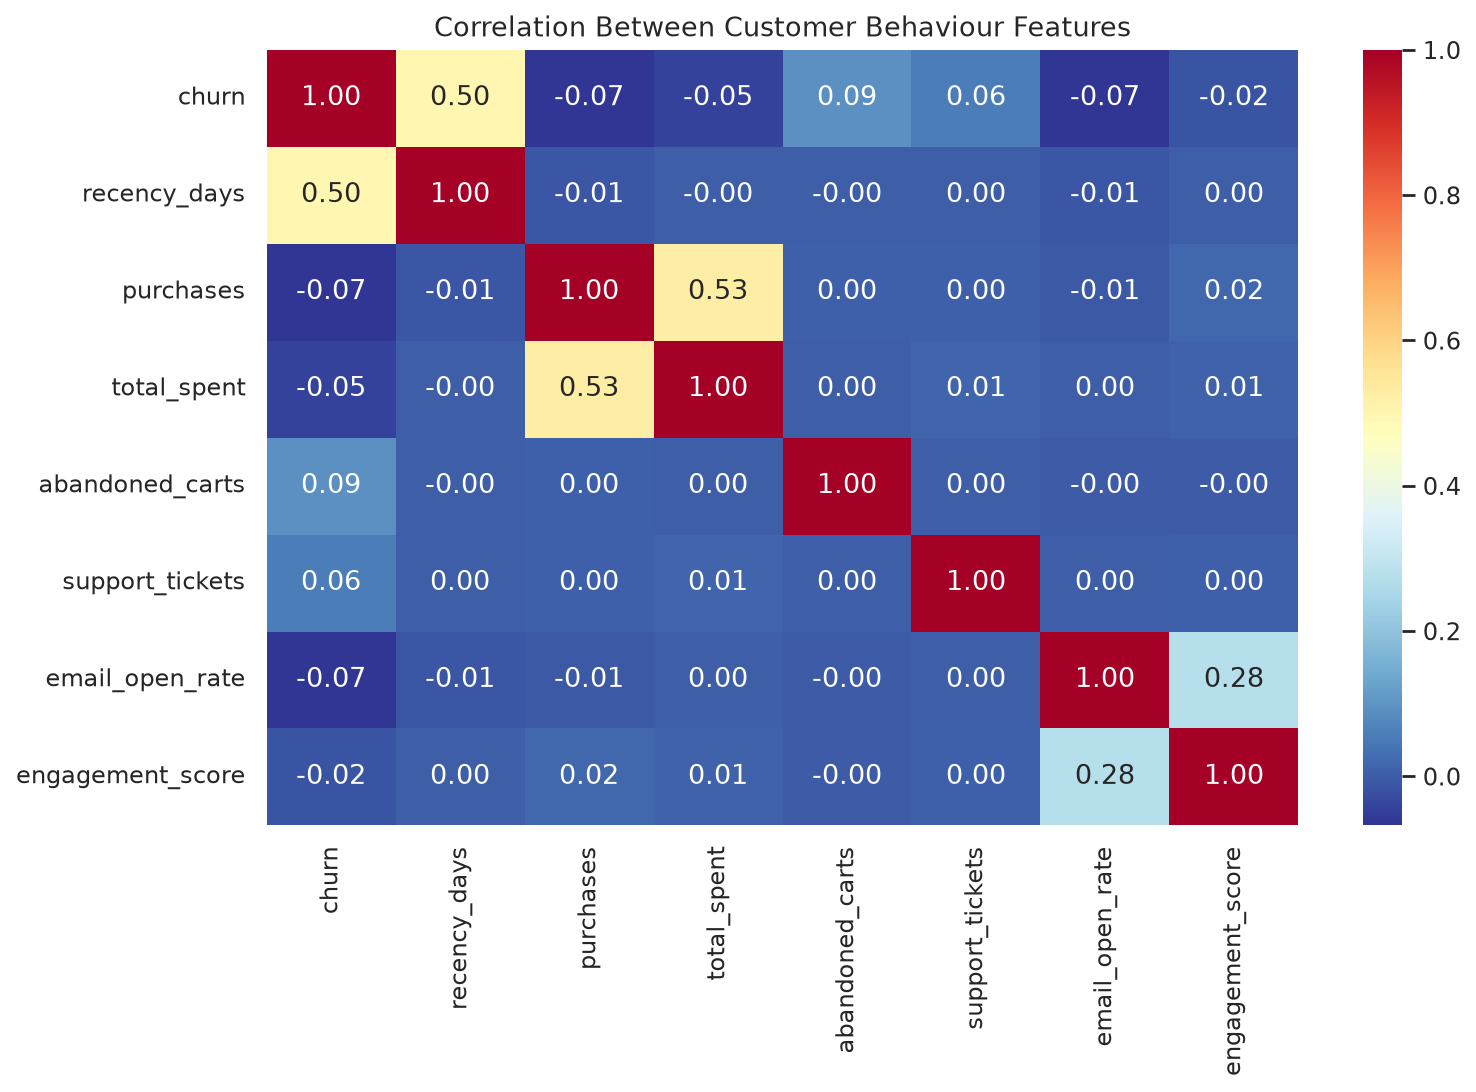

In [7]:
display(Image(filename="outputs/charts/customer_insights.png"))
display(Image(filename="outputs/charts/correlation_heatmap.png"))

## 5. Big-data tool utilisation: Dask

Dask was selected because it provides a familiar pandas-like interface while splitting data into partitions that can be processed in parallel. Here, eight partitions simulate a distributed workflow. The approach can later scale to data larger than one machine's memory or run on a multi-machine Dask cluster.

In [8]:
dask_city_analysis = run_dask_analysis(clean_df)
dask_city_analysis

,customers,average_spend,churn_rate
city,,,
Takoradi,1079,454.71,24.75
Cape Coast,850,454.22,26.82
Kumasi,2642,445.76,26.95
Accra,5018,443.21,26.98
Tema,1591,437.09,27.53
Tamale,820,436.69,26.10


## 6. Predictive modelling

A Random Forest classifier predicts whether a customer will churn. The preprocessing pipeline:

- imputes numeric and categorical values;
- standardises numeric features;
- one-hot encodes categorical features;
- prevents leakage by fitting transformations only on training data.

Performance is measured using accuracy, precision, recall, F1-score, ROC-AUC, a confusion matrix, and stratified five-fold cross-validation. F1 and ROC-AUC are important because churn classes may be imbalanced.

In [9]:
model, model_metrics, feature_importance = train_churn_model(clean_df)
model_metrics

{'accuracy': 0.7754,
 'precision': 0.571,
 'recall': 0.6501,
 'f1_score': 0.608,
 'roc_auc': 0.8062,
 'cross_validation_f1_mean': 0.5906,
 'cross_validation_f1_std': 0.0055,
 'test_customers': 2400}

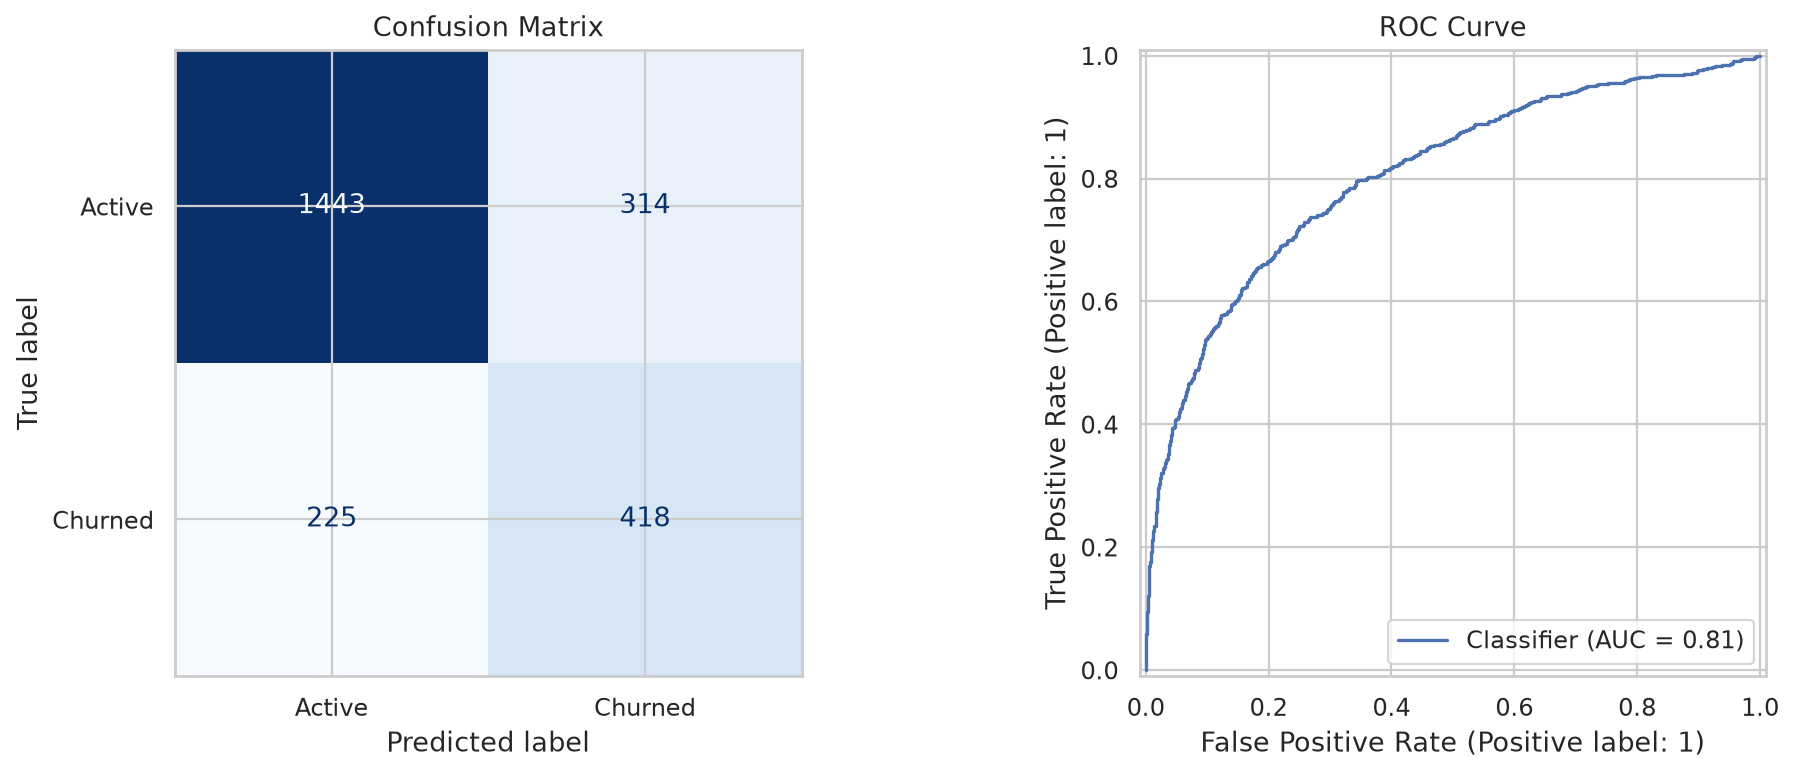

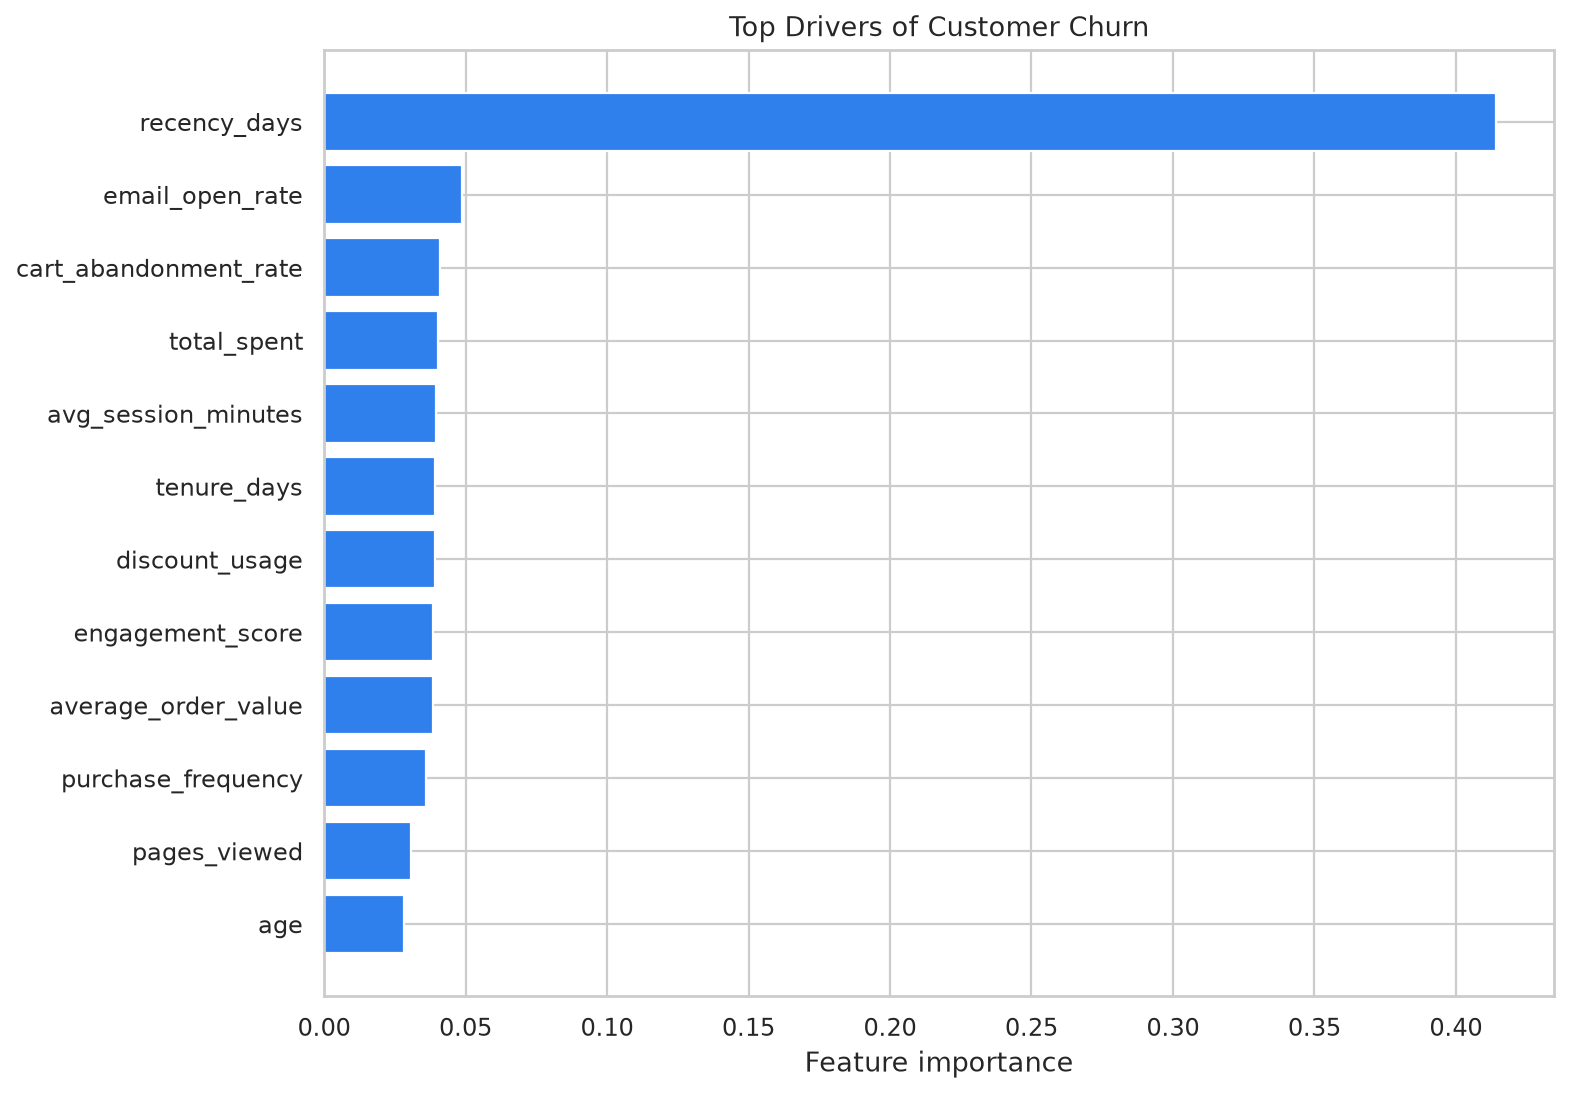

,feature,importance
0,numeric__recency_days,0.414029
1,numeric__email_open_rate,0.048759
2,numeric__cart_abandonment_rate,0.040798
3,numeric__total_spent,0.040151
4,numeric__avg_session_minutes,0.039570
5,numeric__tenure_days,0.039187
6,numeric__discount_usage,0.039122
7,numeric__engagement_score,0.038586
8,numeric__average_order_value,0.038410
9,numeric__purchase_frequency,0.036028


In [10]:
display(Image(filename="outputs/charts/model_evaluation.png"))
display(Image(filename="outputs/charts/feature_importance.png"))
feature_importance.head(12)

## 7. Actionable business recommendations

The following recommendations combine the exploratory findings with the model's most important churn drivers.

In [11]:
recommendations = create_business_recommendations(clean_df, feature_importance)
for number, recommendation in enumerate(recommendations, 1):
    print(f"{number}. {recommendation}")

1. Launch automated re-engagement messages before customers reach about 94 days without purchasing.
2. Prioritize retention offers for Basic members, the membership group with the highest observed churn rate.
3. Send cart reminders and limited-time incentives to customers with high cart-abandonment rates.
4. Route customers with repeated support tickets to proactive service follow-ups before dissatisfaction causes churn.
5. Create a CRM risk segment from the model probability and contact the highest-risk customers first.
6. Monitor recency_days closely because the trained model identified it as the strongest churn driver.


## 8. Conclusion and limitations

This workflow shows how customer behaviour can be converted into churn risk and useful retention actions. The model is suitable as a proof of concept, not as a final production system, because its training data is synthetic.

Before production deployment, the business should retrain the model on consented real customer data, check fairness across customer groups, monitor performance and data drift, protect personal information, and periodically review whether retention actions actually reduce churn.